Introduction

In recent years, social cohesion has emerged as a central topic in comparative political economy, political sociology, and policy-oriented social science. It is often used to explain variation in democratic stability, welfare, and collective norms. Despite this rise in prominence, most empirical work treats cohesion as a unidimensional trait — a spectrum along which societies can be ranked (Schiefer & van der Noll, 2017). This assumes that societies differ in how cohesive they are, rather than by how cohesion is organized.

This paper challenges that assumption. Drawing on theories that describe social cohesion as multi-dimensional, it asks: Are there empirically distinguishable social cohesion regimes across countries in Wave 7 of the World Values Survey, and if so, is membership in these regimes better understood as probabilistic rather than deterministic? To answer these questions, this paper applies a pipeline of Principal Component Analysis (PCA), hierarchical clustering, and Gaussian Mixture Modeling (GMM) to country-level aggregates of 31 indicators taken from the Joint EVS/WVS 2017–2022 dataset across 92 countries.

Literature Review

Theories of social cohesion emphasize varying underlying mechanisms. Drawing on Durkheim (1893), classical sociological perspectives associate cohesion with shared norms, moral integration, and social solidarity. Later work in the fields of political sociology and social capital theory emphasize interpersonal trust and institutional trust as distinct foundations of a cohesive society (Delhey & Newton, 2005). In parallel, theories in political economy and institutionalism highlight confidence in formal institutions, state capacity, and perceived legitimacy as alternative sources of cohesion, particularly in cases where interpersonal trust is limited (Easterly et al., 2006; Mishler & Rose, 2001; Rothstein & Stolle, 2008). These perspectives suggest that social cohesion may arise through multiple equilibria rather than a single pathway. In that case, social cohesion could not be measured using a single index. For example, a society characterized by high generalized trust and voluntary civic participation may exhibit a fundamentally different form of cohesion than a society in which social order is maintained primarily through strong institutions, authority, or in-group bonds. Treating social cohesion as a single index risks collapsing these distinct permutations into a single scalar and obscuring these fundamental differences. Instead, a regime-based approach treats social cohesion as a configuration of attitudes and behaviors that may cluster into qualitatively distinct types.

There has been limited empirical work that has begun to explore regime-based social cohesion—most notably Janmaat (2011), who uses indicators mostly drawn from the 1999 wave of the World Values Survey to identify cross-national cohesion regimes by utilizing cluster analysis. This paper represents a significant departure from single-index measurement of social cohesion. Subsequent regime-oriented studies similarly rely on hard clustering techniques to assign countries to cohesion types based on trust, participation, and related indicators (Green et al., 2009; Delhey et al., 2023). However, regime membership in these is treated as deterministic. Countries are assigned to regimes without considering uncertainty, overlap, or ambiguity in classification. As a result, the existence and sharpness of cohesion regimes are largely assumed rather than tested.

This paper builds on the foundation laid by Janmaat (2011) and others while clearly evolving conceptually and methodologically. Rather than asking which regime each country belongs to, it asks whether cohesion regimes exist as empirically distinct latent structures at all, and if so, how confidently countries can be assigned to them. By modeling regime membership probabilistically, this paper will question whether cohesion regimes are distinct, weakly defined, or overlapping, in addition to addressing whether a regime-based representation of social cohesion is justified at all.

Data

This analysis uses individual-level microdata from the Joint EVS/WVS 2017–2022 dataset (v5.0.0), which harmonizes the World Values Survey Wave 7 and the European Values Study into a single cross-national dataset. The data are publicly available at worldvaluessurvey.org and widely used in comparative political economy, sociology, and political science. The joint dataset was used in preference to the standalone WVS Wave 7 file to ensure fuller European coverage, which is theoretically important given the centrality of Nordic and Western European cases to the social cohesion literature. The aggregated dataset is comprised of 92 countries, with a total sample size of roughly 120,000 individual respondents. National sample sizes typically range from 1,000 to 3,000 respondents per country.

The unit of analysis for this paper is the country in Wave 7, with individual survey responses aggregated to country-level means using the survey-provided equalized weight (wght_eq1000) to create country-level measures of social cohesion. Previous work using the World Values Survey demonstrates that countries occupy distinct positions in a multidimensional cultural space (Inglehart and Welzel, 2005). This aggregation reflects the academic consensus that social cohesion should be treated as a societal property rather than an individual characteristic. Wave 7 provides broad geographic coverage and includes a rich set of indicators related to trust, participation, tolerance, and institutional confidence, making it particularly well suited for a comparative analysis of cohesion structures.

Measurement Framework

Each country is represented as a point in multidimensional cohesion space measured by aggregated indicators. The indicators were selected across four theoretically grounded dimensions: institutional legitimacy, sociocultural acceptance, political participation, and civic belonging, following the framework proposed by Berger-Schmitt (2000) and adapted from the Social Cohesion Radar (Dragolov et al. 2016). In total, 31 indicators are drawn from the joint dataset on the basis of theoretical relevance, cross-national comparability, and data availability. These dimensions are also verified empirically using PCA. 

Institutional legitimacy is captured through ten items measuring confidence in core institutions including churches, armed forces, press, labor unions, police, parliament, civil service, government, political parties, and courts (E069 series). The acceptance dimension comprises three neighbor rejection items measuring unwillingness to live next to people of a different race, immigrants, and homosexuals (A124 series), alongside four interpersonal trust items covering family, neighborhood, people of another religion, and people of another nationality (D001_B, G007 series). Political participation is measured through four items capturing whether respondents have signed a petition, joined a boycott, attended a demonstration, or joined a strike (E025–E028). Civic belonging is operationalized through ten organizational membership items spanning religious, educational, union, party, environmental, professional, sports, consumer, humanitarian, and self-help organizations (A065–A080 series).

All indicators are recoded so that higher values reflect greater social cohesion. Legitimacy, acceptance, and participation items required reverse coding prior to analysis, as higher raw scores on these scales indicate lower cohesion. Indicators are also standardized prior to analysis to ensure comparability and to prevent any single dimension from dominating the clustering results.

In [136]:
import pandas as pd
df = pd.read_csv('Data/EVS_WVS_Joint_Csv_v5_0.csv')
print(df.columns.tolist())
print(df.shape)

/var/folders/2m/_srm4zt516x9bpzcvkd4qvsh0000gn/T/ipykernel_35964/3906942300.py:2: DtypeWarning: Columns (35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Data/EVS_WVS_Joint_Csv_v5_0.csv')


['study', 'wave', 'version', 'versn_s', 'doi_gesis', 'doi_wvsa', 'studytit', 'uniqid', 'intrvwr_id', 'cntry', 'cntry_AN', 'cntrycow', 'year', 'fw_start', 'fw_end', 'cntry_y', 'mode', 'mm_mixed_mode_EVS5', 'mm_mode_fu_EVS5', 'mm_matrix_group_EVS5', 'mm_fw_start_fu_EVS5', 'mm_fw_end_fu_EVS5', 'mm_year_fu_EVS5', 'ivlength', 'ivstart', 'ivstend', 'ivdate', 'mm_v277_fu_EVS5', 'mm_v278a_fu_r_EVS5', 'mm_v279a_fu_r_EVS5', 'lnge_num', 'lnge_iso', 'gwght', 'pwght', 'wght_eq1000', 'reg_nuts1', 'reg_nuts2', 'reg_iso', 'size_5c', 'respint', 'A001', 'A002', 'A003', 'A004', 'A005', 'A006', 'A008', 'A009', 'A170', 'A173', 'A027', 'A029', 'A030', 'A032', 'A034', 'A035', 'A038', 'A039', 'A040', 'A041', 'A042', 'A065', 'A066', 'A067', 'A068', 'A071', 'A072', 'A074', 'A078', 'A079', 'A080_01', 'A080_02', 'A124_02', 'A124_03', 'A124_06', 'A124_08', 'A124_09', 'A165', 'B008', 'C001', 'C001_01', 'C002', 'C002_01', 'D081', 'D026_03', 'D026_05', 'C038', 'C039', 'C041', 'D001_B', 'G007_18_B', 'G007_33_B', 'G007

In [137]:
import numpy as np

df = pd.read_csv('Data/EVS_WVS_Joint_Csv_v5_0.csv', low_memory=False)

id_vars = ['cntry', 'cntry_AN', 'study', 'wght_eq1000']

legitimacy = ['E069_01', 'E069_02', 'E069_04', 'E069_05', 'E069_06',
              'E069_07', 'E069_08', 'E069_11', 'E069_12', 'E069_17']

acceptance = ['A124_02', 'A124_06', 'A124_09', 'D001_B',
              'G007_18_B', 'G007_35_B', 'G007_36_B']

participation = ['E025', 'E026', 'E027', 'E028']

belonging = ['A065', 'A066', 'A067', 'A068', 'A071', 'A072',
             'A074', 'A078', 'A080_01', 'A080_02']

all_vars = id_vars + legitimacy + acceptance + participation + belonging
indicator_cols = legitimacy + acceptance + participation + belonging

df_sub = df[all_vars].copy()
print(df_sub.shape)

(156658, 35)


In [138]:
df_sub.to_csv('Data/df_sub.csv', index=False)
print("Saved successfully")

Saved successfully


Prior to aggregation, several cleaning steps were taken to the individual-level data. The WVS uses negative codes (−5, −4, −2, −1) to dentore various forms of non-response. Negative values across all indicator colums were replaced as missing. Missingness was then examined at the country-variable level. Eight country-variable pairs exhibited complete missingness in a variable, spanning five countries: Andorra and Iceland were missing the armed forces confidence item, Egypt was missing four legitimacy items, and Iran and Tajikistan were missing the homosexual neighbor rejection item. 

Despite this, all 92 countries were retained in the analysis. Individual-level missing values were imputed using scikit-learn's IterativeImputer, which models each variable as a function of all others and has been shown to outperform simpler mean imputation strategies in survey data contexts. Following imputation, all indicators were reverse coded where necessary and country-level means were computed using the equalized survey weight. The resulting dataset is a complete 92×31 matrix with no remaining missing values.

In [139]:
# Check min and max of each indicator column to identify missing value codes
indicator_cols = legitimacy + acceptance + participation + belonging

for col in indicator_cols:
    print(f"{col}: min={df_sub[col].min()}, max={df_sub[col].max()}, "
          f"unique={sorted(df_sub[col].unique())}")

E069_01: min=-5, max=4, unique=[-5, -2, -1, 1, 2, 3, 4]
E069_02: min=-5, max=4, unique=[-5, -4, -2, -1, 1, 2, 3, 4]
E069_04: min=-5, max=4, unique=[-5, -2, -1, 1, 2, 3, 4]
E069_05: min=-5, max=4, unique=[-5, -2, -1, 1, 2, 3, 4]
E069_06: min=-5, max=4, unique=[-5, -4, -2, -1, 1, 2, 3, 4]
E069_07: min=-5, max=4, unique=[-5, -2, -1, 1, 2, 3, 4]
E069_08: min=-5, max=4, unique=[-5, -2, -1, 1, 2, 3, 4]
E069_11: min=-5, max=4, unique=[-5, -4, -2, -1, 1, 2, 3, 4]
E069_12: min=-5, max=4, unique=[-5, -2, -1, 1, 2, 3, 4]
E069_17: min=-5, max=4, unique=[-5, -4, -2, -1, 1, 2, 3, 4]
A124_02: min=-5, max=1, unique=[-5, -2, -1, 0, 1]
A124_06: min=-5, max=1, unique=[-5, -4, -2, -1, 0, 1]
A124_09: min=-5, max=1, unique=[-5, -4, -2, -1, 0, 1]
D001_B: min=-5, max=4, unique=[-5, -2, -1, 1, 2, 3, 4]
G007_18_B: min=-5, max=4, unique=[-5, -2, -1, 1, 2, 3, 4]
G007_35_B: min=-5, max=4, unique=[-5, -2, -1, 1, 2, 3, 4]
G007_36_B: min=-5, max=4, unique=[-5, -2, -1, 1, 2, 3, 4]
E025: min=-5, max=3, unique=[-5, -2, 

In [140]:
df_sub[indicator_cols] = df_sub[indicator_cols].replace([-5, -4, -2, -1], np.nan)

print(df_sub[indicator_cols].isnull().sum())

E069_01       4019
E069_02       7755
E069_04       3576
E069_05      12502
E069_06       3355
E069_07       5551
E069_08       5547
E069_11       5069
E069_12       5859
E069_17       5857
A124_02       3510
A124_06       4224
A124_09       6062
D001_B         592
G007_18_B     1649
G007_35_B     8729
G007_36_B     8429
E025          5626
E026          7740
E027          5895
E028          7602
A065          2199
A066          2368
A067          2560
A068          2539
A071          2593
A072          2812
A074          2202
A078          2972
A080_01       2582
A080_02       2864
dtype: int64


In [ ]:
# Missingness by variable and country
missingness_by_var = df_sub.groupby('cntry_AN')[indicator_cols].apply(
    lambda x: x.isnull().mean() * 100
).round(1)

# Summary: mean missingness per country across all variables
country_stats = missingness_by_var.mean(axis=1).reset_index()
country_stats.columns = ['cntry_AN', 'mean_pct_missing']
country_total = df_sub.groupby('cntry_AN').size().reset_index(name='total_n')
country_stats = country_stats.merge(country_total, on='cntry_AN')
print(country_stats.sort_values('mean_pct_missing', ascending=False).to_string())

# Flag any country-variable pairs with 100% missingness
print("\nCountry-variable pairs with 100% missingness:")
fully_missing = missingness_by_var[missingness_by_var == 100].stack().reset_index()
fully_missing.columns = ['cntry_AN', 'variable', 'pct_missing']
print(fully_missing.to_string(index=False))

   cntry_AN  mean_pct_missing  total_n
24       EG         17.038710     1200
43       JP          9.103226     1353
9        BG          7.896774     1558
49       LT          7.664516     1448
66       NZ          7.538710     1057
19       CZ          6.945161     3011
69       PK          6.690323     1995
23       EE          6.335484     1304
6        AZ          5.996774     1800
64       NL          5.945161     4549
74       RS          5.838710     2545
85       UA          5.754839     2901
37       IN          5.754839     1692
81       TJ          5.441935     1200
73       RO          4.848387     2870
40       IS          4.690323     1624
42       JO          4.529032     1203
70       PL          4.503226     1352
54       MK          4.200000     1117
39       IR          4.129032     1499
20       DE          4.119355     3698
47       KZ          4.000000     1276
12       BY          3.945161     1548
41       IT          3.864516     2277
75       RU          3.80

In [142]:
# For the zero-complete countries, check which variables are entirely missing
zero_countries = ['AD', 'EG', 'TJ', 'IR', 'IS']

for cntry in zero_countries:
    subset = df_sub[df_sub['cntry_AN'] == cntry][indicator_cols]
    all_missing = [col for col in indicator_cols if subset[col].isna().all()]
    print(f"{cntry}: fully missing {all_missing}")

AD: fully missing ['E069_02']
EG: fully missing ['E069_02', 'E069_06', 'E069_11', 'E069_17']
TJ: fully missing ['A124_09']
IR: fully missing ['A124_09']
IS: fully missing ['E069_02']


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(max_iter=3, random_state=42)
df_sub[indicator_cols] = imputer.fit_transform(df_sub[indicator_cols])

print(f"Missing values remaining after individual-level imputation: {df_sub[indicator_cols].isnull().sum().sum()}")

Missing values remaining after individual-level imputation: 0
Countries: 92


/opt/anaconda3/lib/python3.12/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [144]:
df_sub.to_csv('Data/df_sub.csv', index=False)
print("Saved")

Saved


In [145]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist

df_sub = pd.read_csv('Data/df_sub.csv')

In [146]:
# Reverse-code inverted variables
for col in legitimacy:
    df_sub[col] = 5 - df_sub[col]
for col in ['A124_02', 'A124_06', 'A124_09']:
    df_sub[col] = 1 - df_sub[col]
for col in ['D001_B', 'G007_18_B', 'G007_35_B', 'G007_36_B']:
    df_sub[col] = 5 - df_sub[col]
for col in ['E025', 'E026', 'E027', 'E028']:
    df_sub[col] = 4 - df_sub[col]

In [ ]:
df_country = (
    df_sub
    .groupby('cntry_AN')
    .apply(lambda g: pd.Series({
        col: np.average(g[col], weights=g['wght_eq1000'])
        for col in indicator_cols
    }), include_groups=False)
    .reset_index()
)

print(df_country.shape)
print(f"Missing values after aggregation: {df_country[indicator_cols].isnull().sum().sum()}")

# Country-level iterative imputation for any remaining instrument-level gaps
if df_country[indicator_cols].isnull().sum().sum() > 0:
    from sklearn.experimental import enable_iterative_imputer
    from sklearn.impute import IterativeImputer
    
    imputer_country = IterativeImputer(max_iter=10, random_state=42)
    df_country[indicator_cols] = imputer_country.fit_transform(
        df_country[indicator_cols]
    )

(92, 32)
Missing values after aggregation: 0
No country-level imputation needed


Exploratory Data Analysis

Descriptive Statistics

Country level means were examined across all 31 indicators. Legitimacy items cluster between 2.0 and 3.1 on a 1–4 scale, indicating low-to-moderate institutional confidence across most countries. The acceptance dimension shows the widest cross-national variation, with the homosexual neighbor rejection item (A124_09) exhibiting a range of 0.91, making it among the most discriminating variables for regime detection.

In [148]:
desc = df_country[indicator_cols].describe().T.round(3)
desc['range'] = desc['max'] - desc['min']
print(desc[['mean', 'std', 'min', 'max', 'range']])

            mean    std    min    max  range
E069_01    2.739  0.462  1.763  3.928  2.165
E069_02    2.838  0.383  1.885  3.718  1.833
E069_04    2.247  0.293  1.671  2.891  1.220
E069_05    2.258  0.326  1.575  3.050  1.475
E069_06    2.688  0.389  1.718  3.636  1.918
E069_07    2.168  0.451  1.300  3.301  2.001
E069_08    2.411  0.369  1.480  3.115  1.635
E069_11    2.289  0.455  1.556  3.436  1.880
E069_12    1.967  0.392  1.346  3.273  1.927
E069_17    2.512  0.407  1.541  3.229  1.688
A124_02    0.835  0.129  0.296  0.993  0.697
A124_06    0.775  0.148  0.272  0.975  0.703
A124_09    0.579  0.275  0.062  0.975  0.913
D001_B     3.767  0.132  3.352  3.984  0.632
G007_18_B  2.864  0.247  2.104  3.418  1.314
G007_35_B  2.375  0.319  1.576  3.137  1.561
G007_36_B  2.308  0.365  1.604  3.210  1.606
E025       1.866  0.425  1.186  2.775  1.589
E026       1.484  0.260  1.098  2.269  1.171
E027       1.665  0.246  1.082  2.223  1.141
E028       1.415  0.211  1.031  1.883  0.852
A065      

Dimension Distributions

All four dimensions show substantial cross-national variation around their respective means, confirming that each dimension discriminates meaningfully between countries and that none is redundant for the purposes of regime detection.

In [149]:
df_country['legitimacy_mean']    = df_country[legitimacy].mean(axis=1)
df_country['acceptance_mean']    = df_country[acceptance].mean(axis=1)
df_country['participation_mean'] = df_country[participation].mean(axis=1)
df_country['belonging_mean']     = df_country[belonging].mean(axis=1)

dim_cols = ['legitimacy_mean', 'acceptance_mean', 'participation_mean', 'belonging_mean']
print(df_country[['cntry_AN'] + dim_cols].sort_values('legitimacy_mean').round(3).to_string())

   cntry_AN  legitimacy_mean  acceptance_mean  participation_mean  belonging_mean
67       PE            1.790            1.656               1.550           0.109
89       VE            1.870            1.846               1.533           0.074
34       HR            1.887            2.043               1.921           0.111
32       GT            1.921            1.802               1.614           0.351
59       MX            1.923            1.787               1.400           0.224
1        AL            1.960            1.912               1.431           0.019
10       BO            1.967            1.675               1.558           0.247
62       NI            2.000            1.670               1.356           0.287
9        BG            2.020            1.824               1.458           0.062
3        AR            2.024            2.133               1.673           0.119
17       CO            2.031            1.769               1.737           0.375
24       EG     

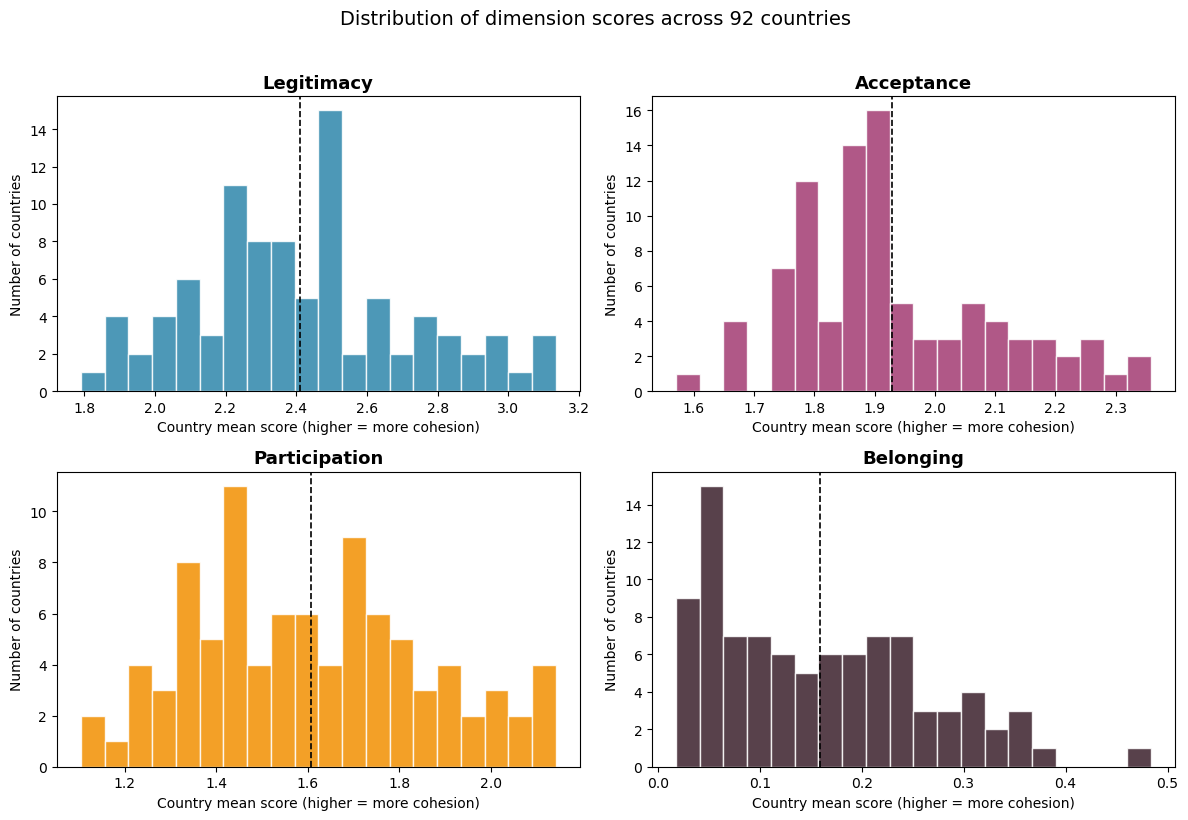

In [150]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
dims = [('legitimacy_mean',    'Legitimacy',    '#2E86AB'),
        ('acceptance_mean',    'Acceptance',    '#A23B72'),
        ('participation_mean', 'Participation', '#F18F01'),
        ('belonging_mean',     'Belonging',     '#3B1F2B')]

for ax, (col, label, color) in zip(axes.flatten(), dims):
    ax.hist(df_country[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df_country[col].mean(), color='black', linestyle='--', linewidth=1.2)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Country mean score (higher = more cohesion)')
    ax.set_ylabel('Number of countries')

plt.suptitle('Distribution of dimension scores across 92 countries', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('Figures/dim_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation Structure

For the most part, indicators correlate most strongly within their respective theoretical dimensions, particularly legitimacy and belonging. Cross-dimension correlations are generally modest, providing preliminary evidence that the four dimensions capture distinct aspects of social cohesion rather than a single underlying factor.

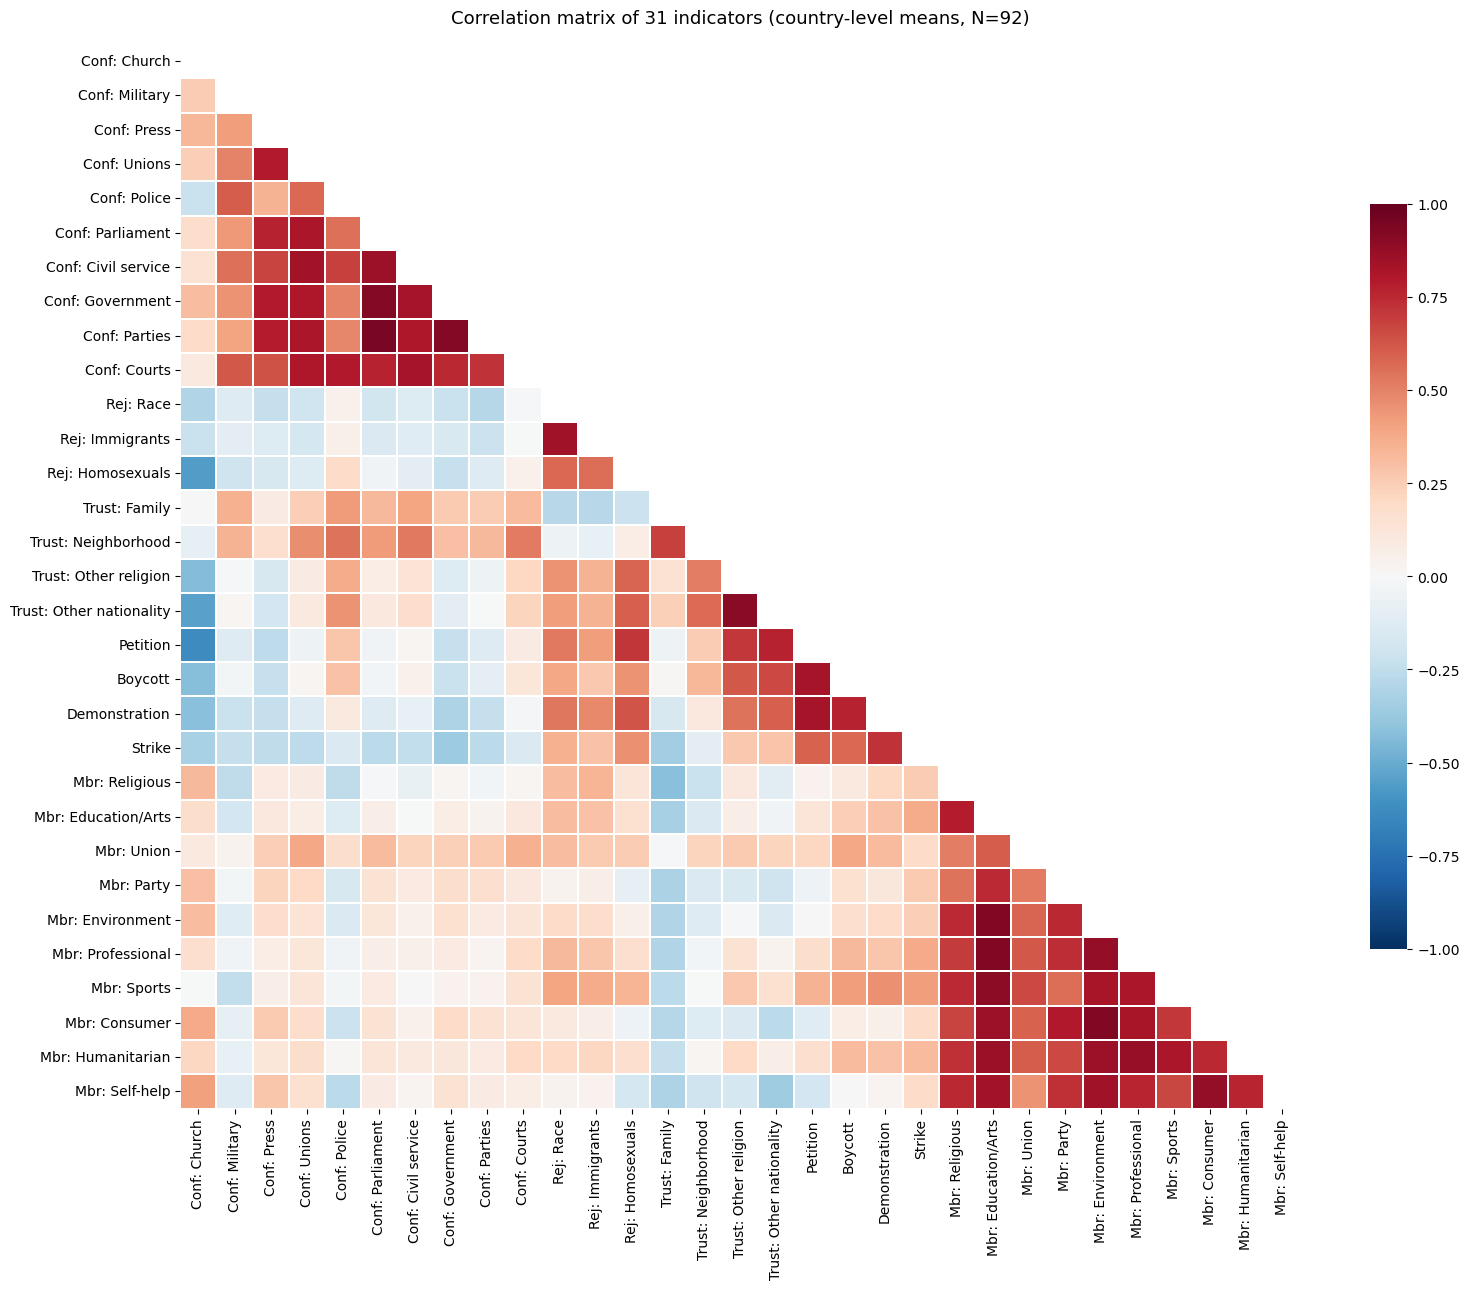

In [151]:
corr = df_country[indicator_cols].corr()

# Label map for readability
labels = {
    'E069_01':'Conf: Church','E069_02':'Conf: Military','E069_04':'Conf: Press',
    'E069_05':'Conf: Unions','E069_06':'Conf: Police','E069_07':'Conf: Parliament',
    'E069_08':'Conf: Civil service','E069_11':'Conf: Government',
    'E069_12':'Conf: Parties','E069_17':'Conf: Courts',
    'A124_02':'Rej: Race','A124_06':'Rej: Immigrants','A124_09':'Rej: Homosexuals',
    'D001_B':'Trust: Family','G007_18_B':'Trust: Neighborhood',
    'G007_35_B':'Trust: Other religion','G007_36_B':'Trust: Other nationality',
    'E025':'Petition','E026':'Boycott','E027':'Demonstration','E028':'Strike',
    'A065':'Mbr: Religious','A066':'Mbr: Education/Arts','A067':'Mbr: Union',
    'A068':'Mbr: Party','A071':'Mbr: Environment','A072':'Mbr: Professional',
    'A074':'Mbr: Sports','A078':'Mbr: Consumer','A080_01':'Mbr: Humanitarian',
    'A080_02':'Mbr: Self-help'
}

corr_labeled = corr.rename(index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr_labeled, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Correlation matrix of 31 indicators (country-level means, N=92)',
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('Figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Feature Clustering

Hierarchical clustering of the 31 indicators based on their inter-correlations recovers groupings that mostly correspond to the four theoretical dimensions, although there is some cause for concern with the acceptance and political participation dimensions which seem to have merged.

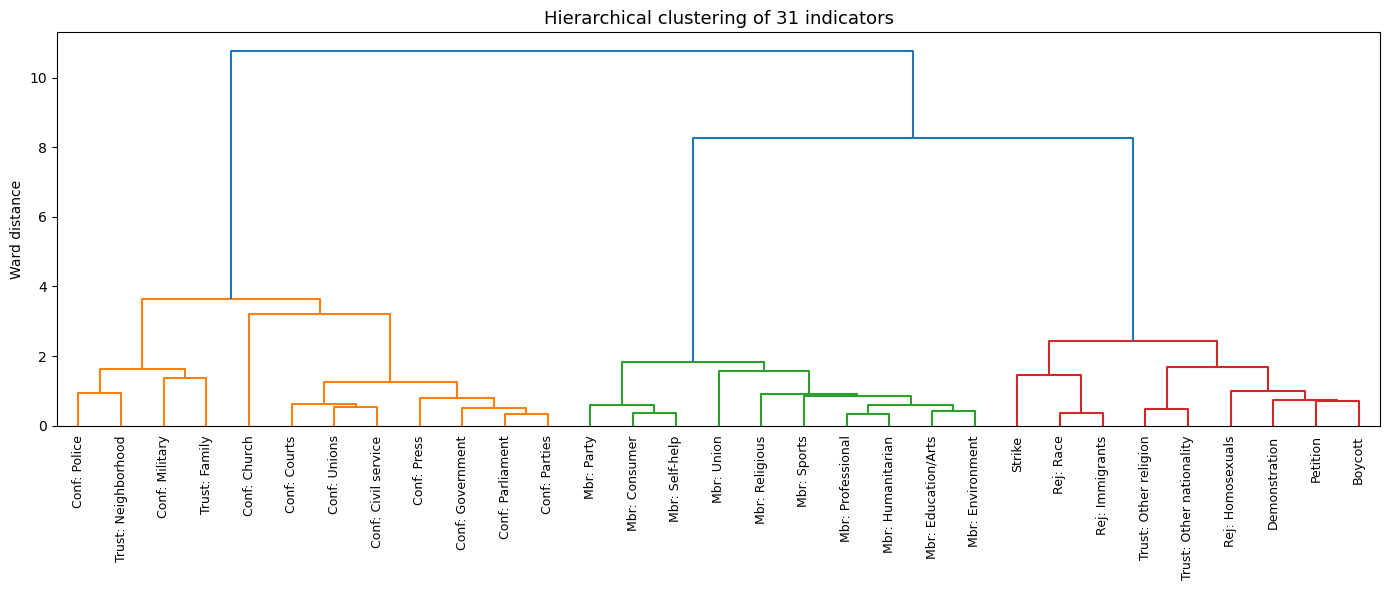

In [152]:
corr_dist = 1 - df_country[indicator_cols].corr()
linkage_vars = hierarchy.linkage(pdist(corr_dist), method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
hierarchy.dendrogram(linkage_vars, labels=[labels[c] for c in indicator_cols],
                     leaf_rotation=90, leaf_font_size=9, ax=ax,
                     color_threshold=0.7*max(linkage_vars[:,2]))
ax.set_title('Hierarchical clustering of 31 indicators', fontsize=13)
ax.set_ylabel('Ward distance')
plt.tight_layout()
plt.savefig('Figures/feature_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

Principal Component Analysis

PCA was applied to the standardized 92x31 indicator matrix to examine the covariance structure among cohesion indicators prior to clustering. The first four components collectively explain 77.3% of the variance, with no single component dominating-—PC1 accounts for 28.1%, PC2 for 24.5%, PC3 for 19.7%, and PC4 for 5.0%. The absence of a dominant first component is itself a substantive finding: it suggests there is no single latent "general cohesion" factor underlying the data, and that social cohesion is genuinely multidimensional. 

Inspection of the loadings reveals interpretable structure across the four components. PC1 is defined primarily by the civic belonging items, with all ten organizational membership indicators loading. PC2 captures institutional confidence, with the legitimacy items loading. PC3 reflects a combination of social openness and civic engagement. PC4 contrasts outgroup rejection with ingroup trust. Since the fourth PC explained 5%, all four components were retained for use as input to the subsequent clustering and mixture modeling steps.

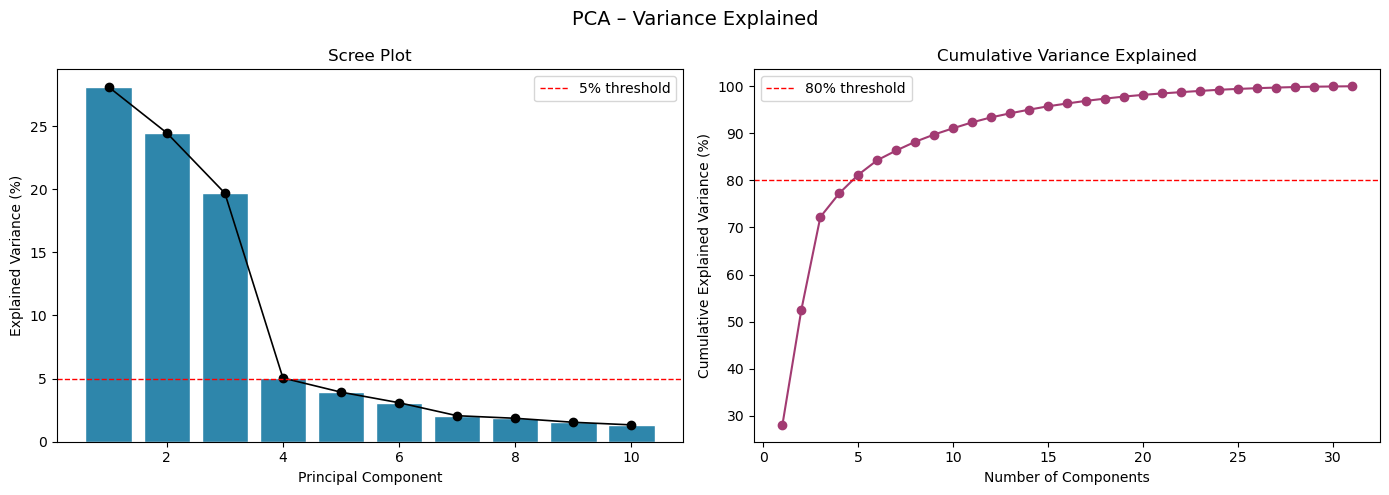

Variance explained by first 6 components:
  PC1: 28.1%  (cumulative: 28.1%)
  PC2: 24.5%  (cumulative: 52.5%)
  PC3: 19.7%  (cumulative: 72.2%)
  PC4: 5.0%  (cumulative: 77.3%)
  PC5: 3.9%  (cumulative: 81.2%)
  PC6: 3.1%  (cumulative: 84.3%)


In [153]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

X = StandardScaler().fit_transform(df_country[indicator_cols])
pca = PCA()
pca.fit(X)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Explained variance
axes[0].bar(range(1, 11), pca.explained_variance_ratio_[:10] * 100,
            color='#2E86AB', edgecolor='white')
axes[0].plot(range(1, 11), pca.explained_variance_ratio_[:10] * 100,
             'o-', color='black', linewidth=1.2)
axes[0].axhline(y=5, color='red', linestyle='--', linewidth=1, label='5% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].legend()

# Cumulative variance
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(cumvar) + 1), cumvar, 'o-', color='#A23B72', linewidth=1.5)
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=1, label='80% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()

plt.suptitle('PCA – Variance Explained', fontsize=14)
plt.tight_layout()
plt.savefig('Figures/pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

print("Variance explained by first 6 components:")
for i, v in enumerate(pca.explained_variance_ratio_[:6]):
    print(f"  PC{i+1}: {v*100:.1f}%  (cumulative: {cumvar[i]:.1f}%)")

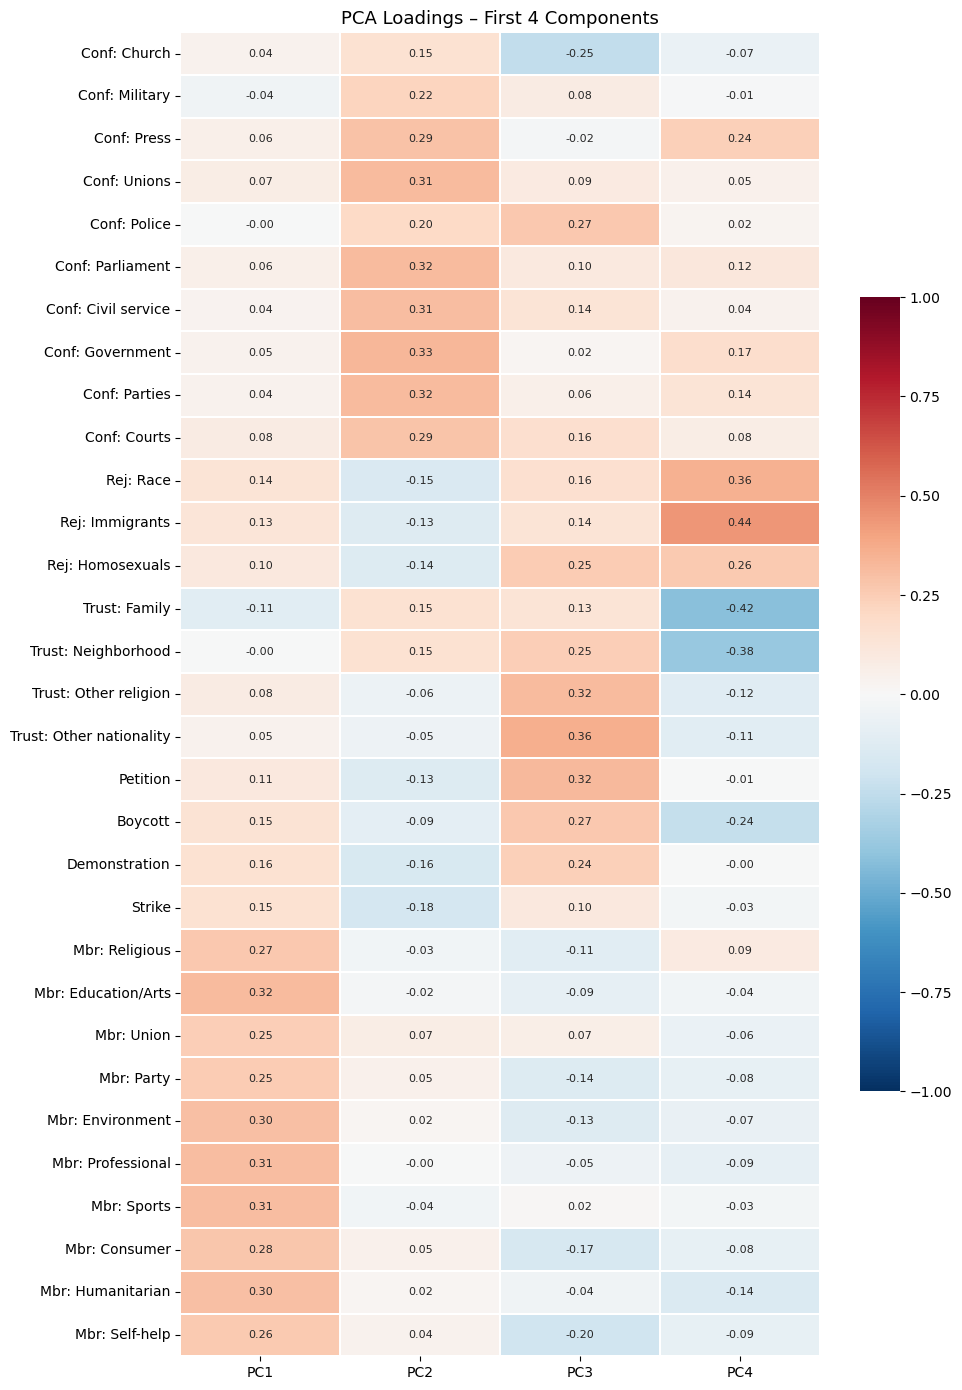

In [154]:
n_components = 4  # adjust after seeing scree plot
pca_final = PCA(n_components=n_components)
scores = pca_final.fit_transform(X)

loadings = pd.DataFrame(
    pca_final.components_.T,
    index=[labels[c] for c in indicator_cols],
    columns=[f'PC{i+1}' for i in range(n_components)]
)

fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(loadings, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.6},
            annot=True, fmt='.2f', annot_kws={'size': 8})
ax.set_title(f'PCA Loadings – First {n_components} Components', fontsize=13)
plt.tight_layout()
plt.savefig('Figures/pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

In [155]:
# ── Country code to full name mapping ────────────────────────────────────────
country_names = {
    'AF': 'Afghanistan', 'AL': 'Albania', 'DZ': 'Algeria', 'AO': 'Angola',
    'AR': 'Argentina', 'AM': 'Armenia', 'AU': 'Australia', 'AT': 'Austria',
    'AZ': 'Azerbaijan', 'BD': 'Bangladesh', 'BY': 'Belarus', 'BO': 'Bolivia',
    'BA': 'Bosnia', 'BR': 'Brazil', 'BG': 'Bulgaria', 'BF': 'Burkina Faso',
    'CA': 'Canada', 'CL': 'Chile', 'CN': 'China', 'CO': 'Colombia',
    'HR': 'Croatia', 'CY': 'Cyprus', 'CZ': 'Czechia', 'DK': 'Denmark',
    'EC': 'Ecuador', 'EG': 'Egypt', 'ET': 'Ethiopia', 'FI': 'Finland',
    'FR': 'France', 'GE': 'Georgia', 'DE': 'Germany', 'GH': 'Ghana',
    'GR': 'Greece', 'GT': 'Guatemala', 'HU': 'Hungary', 'IN': 'India',
    'ID': 'Indonesia', 'IQ': 'Iraq', 'IR': 'Iran', 'IT': 'Italy',
    'JP': 'Japan', 'JO': 'Jordan', 'KZ': 'Kazakhstan', 'KE': 'Kenya',
    'KR': 'South Korea', 'KW': 'Kuwait', 'KG': 'Kyrgyzstan', 'LB': 'Lebanon',
    'LY': 'Libya', 'LT': 'Lithuania', 'MO': 'Macao', 'MY': 'Malaysia',
    'ML': 'Mali', 'MX': 'Mexico', 'MD': 'Moldova', 'MN': 'Mongolia',
    'ME': 'Montenegro', 'MA': 'Morocco', 'MM': 'Myanmar', 'NL': 'Netherlands',
    'NZ': 'New Zealand', 'NI': 'Nicaragua', 'NG': 'Nigeria', 'MK': 'North Macedonia',
    'NO': 'Norway', 'PK': 'Pakistan', 'PE': 'Peru', 'PH': 'Philippines',
    'PL': 'Poland', 'PT': 'Portugal', 'PR': 'Puerto Rico', 'RO': 'Romania',
    'RU': 'Russia', 'RS': 'Serbia', 'SK': 'Slovakia', 'SI': 'Slovenia',
    'ZA': 'South Africa', 'ES': 'Spain', 'SE': 'Sweden', 'CH': 'Switzerland',
    'TW': 'Taiwan', 'TJ': 'Tajikistan', 'TZ': 'Tanzania', 'TH': 'Thailand',
    'TN': 'Tunisia', 'TR': 'Turkey', 'UA': 'Ukraine', 'GB': 'Great Britain',
    'US': 'United States', 'UY': 'Uruguay', 'UZ': 'Uzbekistan',
    'VE': 'Venezuela', 'VN': 'Vietnam', 'ZW': 'Zimbabwe',
    'EE': 'Estonia', 'HK': 'Hong Kong', 'LV': 'Latvia',
    'MV': 'Maldives', 'NIR': 'Northern Ireland',
    'AD': 'Andorra', 'IS': 'Iceland', 'SG': 'Singapore'
}

df_country['country_name'] = df_country['cntry_AN'].map(country_names)

Hierarchical Clustering

Ward linkage hierarchical clustering was applied to both the raw standardized indicators and the four principal component scores to assess whether the data exhibits natural groupings and to inform the choice of the number of regimes for the Gaussian mixture model. The two dendrograms were compared using the Adjusted Rand Index (ARI) across a range of candidate solutions. ARI increases substantially from k=3 (0.411) to k=6 (0.706), at which point it peaks before declining slightly at k=7 (0.626) and stabilizing thereafter. This suggests that a six-regime solution captures the most consistent grouping structure across the two input representations.

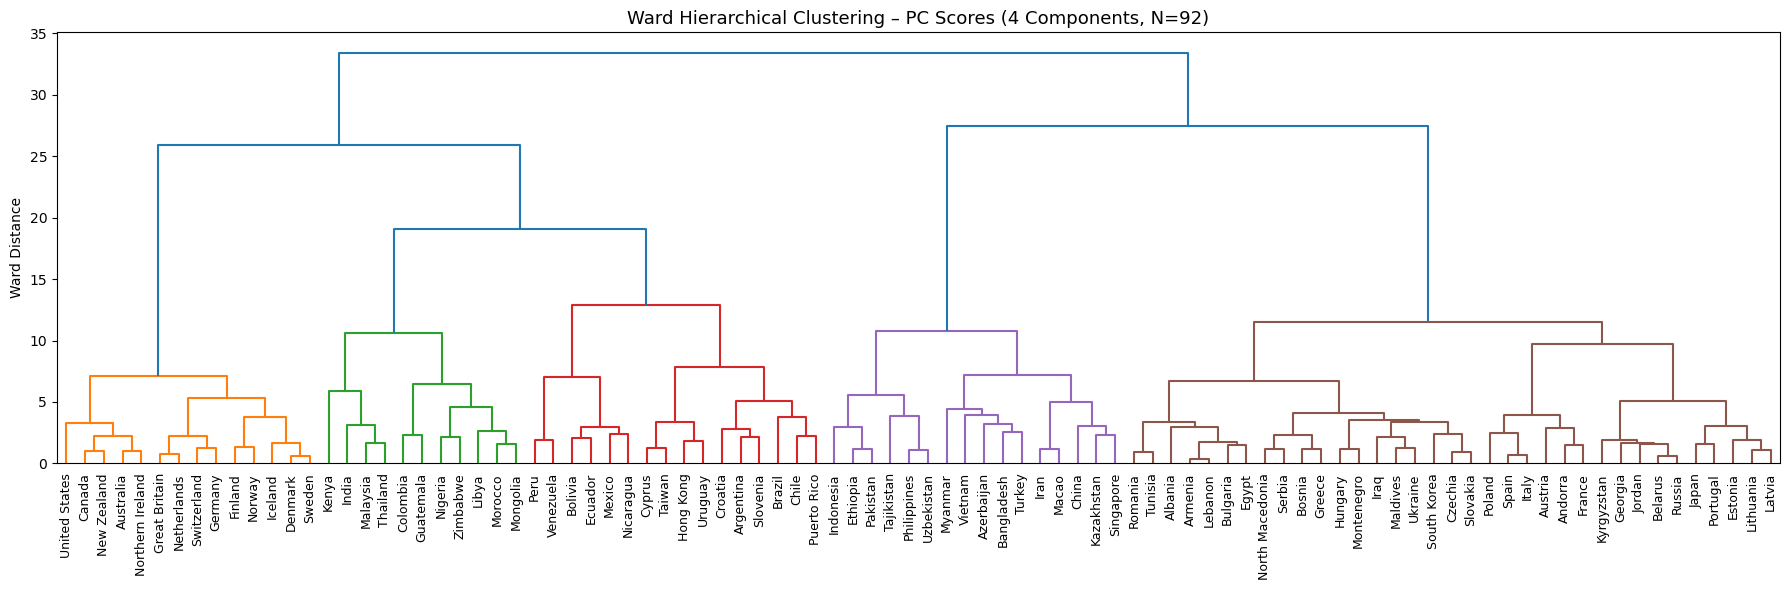

Last 10 merge heights:
[7.829753377451282, 9.72345788794965, 10.600299211936484, 10.769328832826721, 11.533168371192358, 12.881003941481918, 19.100391059715943, 25.88989281266497, 27.48276124170294, 33.41049125266836]


In [189]:
# ── Hierarchical Clustering on PC Scores ────────────────────────────────────
X_raw = StandardScaler().fit_transform(df_country[indicator_cols])
linkage_raw = hierarchy.linkage(X_raw, method='ward')
from sklearn.decomposition import PCA

# Compute PC scores (4 components)
pca_clust = PCA(n_components=4)
X_pca = pca_clust.fit_transform(X_raw)

linkage_pca = hierarchy.linkage(X_pca, method='ward')

fig, ax = plt.subplots(figsize=(18, 6))
hierarchy.dendrogram(linkage_pca, labels=df_country['country_name'].values,
                     leaf_rotation=90, leaf_font_size=9, ax=ax,
                     color_threshold=0.4*max(linkage_pca[:,2]))
ax.set_title('Ward Hierarchical Clustering – PC Scores (4 Components, N=92)', fontsize=13)
ax.set_ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('Figures/hclust_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print("Last 10 merge heights:")
print(sorted(linkage_pca[:, 2])[-10:])

In [ ]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import adjusted_rand_score

for k in [3, 4, 5, 6, 7, 8]:
    labels_raw = fcluster(linkage_raw, k, criterion='maxclust')
    labels_pca = fcluster(linkage_pca, k, criterion='maxclust')
    ari = adjusted_rand_score(labels_raw, labels_pca)
    print(f"k={k}: ARI = {ari:.3f}")

k=3: ARI = 0.411
k=4: ARI = 0.587
k=5: ARI = 0.597
k=6: ARI = 0.706
k=7: ARI = 0.626
k=8: ARI = 0.635


Gaussian Mixture Models

Gaussian mixture models were estimated using the Expectation-Maximization algorithm across covariance structures (full, tied, diagonal, spherical) and k=2 through k=8, using principal component scores as input. Full covariance models on the raw 31-dimensional indicator matrix were discarded as overfit. Among the remaining specifications, BIC was used as the primary model selection criterion.

A seven-component spherical model produces a lower BIC than the six-component solution but only assigns a single country (Myanmar) to its own regime. A one-country regime is substantively indefensible and suggests the model is fitting an outlier rather than a meaningful latent structure. The primary model is therefore specified as a six-component spherical GMM on the four principal component scores (BIC = 1676.5), which is also the solution most consistent with the hierarchical clustering results (ARI = 0.706).

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_raw = StandardScaler().fit_transform(df_country[indicator_cols])
pca_gmm = PCA(n_components=4)
X_pca = pca_gmm.fit_transform(X_raw)

covariance_types = ['full', 'tied', 'diag', 'spherical']
k_range = range(2, 9)
n_init = 50

results = []
for input_name, X in [('raw', X_raw), ('pca', X_pca)]:
    for cov_type in covariance_types:
        for k in k_range:
            gmm = GaussianMixture(
                n_components=k, covariance_type=cov_type,
                n_init=n_init, random_state=42
            )
            gmm.fit(X)
            results.append({
                'input': input_name, 'cov_type': cov_type,
                'k': k, 'bic': gmm.bic(X), 'aic': gmm.aic(X)
            })

results_df = pd.DataFrame(results)
print(results_df.sort_values('bic').head(10).to_string(index=False))

input  cov_type  k          bic           aic
  raw      full  7 -1223.022079 -10541.030871
  raw      full  6  -569.593591  -8556.098014
  raw      full  8  -332.939566 -10982.452727
  raw      full  5    29.741653  -6625.258402
  pca spherical  7  1646.547945   1543.154613
  pca spherical  8  1653.431885   1534.907822
  pca spherical  4  1660.222289   1602.221151
  pca      diag  3  1661.827893   1596.261390
  pca      diag  2  1664.288925   1621.418519
  pca spherical  5  1668.696461   1595.564593
  pca spherical  3  1674.488136   1631.617730
  pca      tied  4  1674.567367   1601.435498
  pca spherical  6  1676.484516   1588.221915
  pca      tied  5  1678.884782   1593.143970
  pca      tied  3  1679.863067   1619.340141


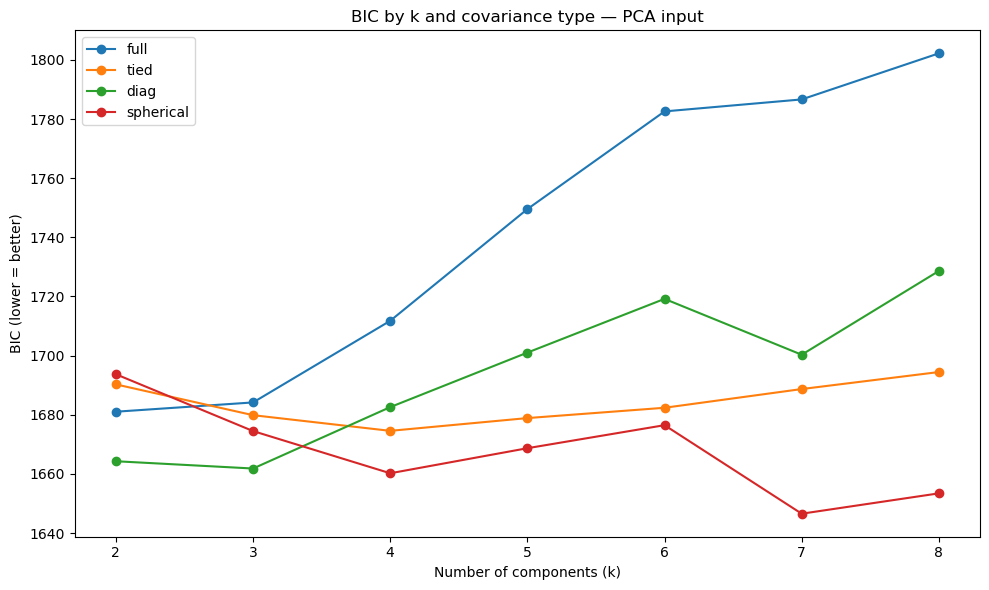

In [176]:
fig, ax = plt.subplots(figsize=(10, 6))

subset = results_df[results_df['input'] == 'pca']
for cov_type in covariance_types:
    sub = subset[subset['cov_type'] == cov_type]
    ax.plot(sub['k'], sub['bic'], marker='o', label=cov_type)

ax.set_title('BIC by k and covariance type — PCA input', fontsize=12)
ax.set_xlabel('Number of components (k)')
ax.set_ylabel('BIC (lower = better)')
ax.legend()
ax.set_xticks(list(k_range))

plt.tight_layout()
plt.savefig('Figures/gmm_bic.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
gmm_k7 = GaussianMixture(
    n_components=7,
    covariance_type='spherical',
    n_init=50,
    random_state=42
)
gmm_k7.fit(X_pca)

labels_k7 = gmm_k7.predict(X_pca)
probs_k7 = gmm_k7.predict_proba(X_pca)
entropy_k7 = -np.sum(probs_k7 * np.log(probs_k7 + 1e-10), axis=1)

df_country['regime_k7'] = labels_k7
df_country['entropy_k7'] = entropy_k7

print("k=7 regime sizes:")
print(df_country['regime_k7'].value_counts().sort_index())
print(f"\nMean entropy: {entropy_k7.mean():.3f}")
print(f"Max entropy: {entropy_k7.max():.3f}")
print(f"\nBIC: {gmm_k7.bic(X_pca):.3f}")

k=7 regime sizes:
regime_k7
0    12
1     1
2     7
3    28
4    13
5    18
6    13
Name: count, dtype: int64

Mean entropy: 0.176
Max entropy: 0.759

BIC: 1646.548

Country assignments:
    country_name  regime_k7
            Peru          0
     Puerto Rico          0
       Nicaragua          0
          Mexico          0
          Brazil          0
         Bolivia          0
           Chile          0
         Ecuador          0
       Argentina          0
       Venezuela          0
        Slovenia          0
         Croatia          0
         Myanmar          1
           Spain          2
          France          2
           Japan          2
           Italy          2
         Andorra          2
        Portugal          2
         Austria          2
         Ukraine          3
          Jordan          3
     South Korea          3
         Lebanon          3
         Tunisia          3
       Lithuania          3
          Latvia          3
        Slovakia          3
 

In [ ]:
print("\nCountry assignments:")
print(df_country[['country_name', 'regime_k7']].sort_values('regime_k7').to_string(index=False))

Results

Regime Structure

The six-component GMM identifies regimes that are both statistically well-separated and substantively interpretable. Mean classification entropy across all 92 countries is 0.157, indicating that most countries are assigned to their primary regime with high confidence. The six regimes vary in size from 7 to 28 countries and exhibit clear geographic and cultural coherence.

In [190]:
gmm_k6 = GaussianMixture(
    n_components=6,
    covariance_type='spherical',
    n_init=50,
    random_state=42
)
gmm_k6.fit(X_pca)

labels_k6 = gmm_k6.predict(X_pca)
probs_k6 = gmm_k6.predict_proba(X_pca)
entropy_k6 = -np.sum(probs_k6 * np.log(probs_k6 + 1e-10), axis=1)

df_country['regime_k6'] = labels_k6
df_country['entropy_k6'] = entropy_k6
for i in range(6):
    df_country[f'prob_regime_{i}'] = probs_k6[:, i]

print("k=6 regime sizes:")
print(df_country['regime_k6'].value_counts().sort_index())
print(f"\nMean entropy: {entropy_k6.mean():.3f}")
print(f"Max entropy: {entropy_k6.max():.3f}")
print(f"\nBIC: {gmm_k6.bic(X_pca):.3f}")

print("\nCountry assignments:")
print(df_country[['country_name', 'regime_k6']].sort_values('regime_k6').to_string(index=False))

k=6 regime sizes:
regime_k6
0     8
1     7
2    14
3    28
4    22
5    13
Name: count, dtype: int64

Mean entropy: 0.157
Max entropy: 0.927

BIC: 1676.485

Country assignments:
    country_name  regime_k6
        Zimbabwe          0
        Thailand          0
         Nigeria          0
        Malaysia          0
           Kenya          0
           India          0
       Indonesia          0
        Ethiopia          0
        Portugal          1
           Japan          1
           Italy          1
          France          1
           Spain          1
         Andorra          1
         Austria          1
         Myanmar          2
       Singapore          2
      Tajikistan          2
      Azerbaijan          2
          Turkey          2
         Vietnam          2
      Bangladesh          2
      Kazakhstan          2
           Macao          2
     Philippines          2
            Iran          2
      Uzbekistan          2
           China          2
        P

Regime Descriptions

Regime 0 (n=8) groups Sub-Saharan African and South/Southeast Asian countries including Zimbabwe, Nigeria, Kenya, India, Indonesia, and Ethiopia. Regime 1 (n=7) captures mostly Southern and Western European democracies including Portugal, Japan, Italy, France, Spain, Andorra, and Austria, characterized by moderate institutional confidence and low outgroup rejection. Regime 2 (n=14) is a high-conformity cluster spanning Central and Southeast Asia, including China, Vietnam, Pakistan, and Uzbekistan, distinguished by high institutional confidence and low civic participation. Regime 3 (n=28) is the largest regime and groups Post-Communist and MENA countries including Russia, Ukraine, Poland, Egypt, and Turkey, reflecting moderate cohesion across all dimensions with high within-regime diversity. Regime 4 (n=22) captures a mixed group of Latin American, transitional, and Global South countries along with some highly developed countries including Hong Kong, Taiwan, and USA. Regime 5 (n=13) cleanly isolates the Western Liberal cluster-—the Nordic countries, Anglophone democracies, and Switzerland-—characterized by high generalized trust, civic participation, and institutional confidence.

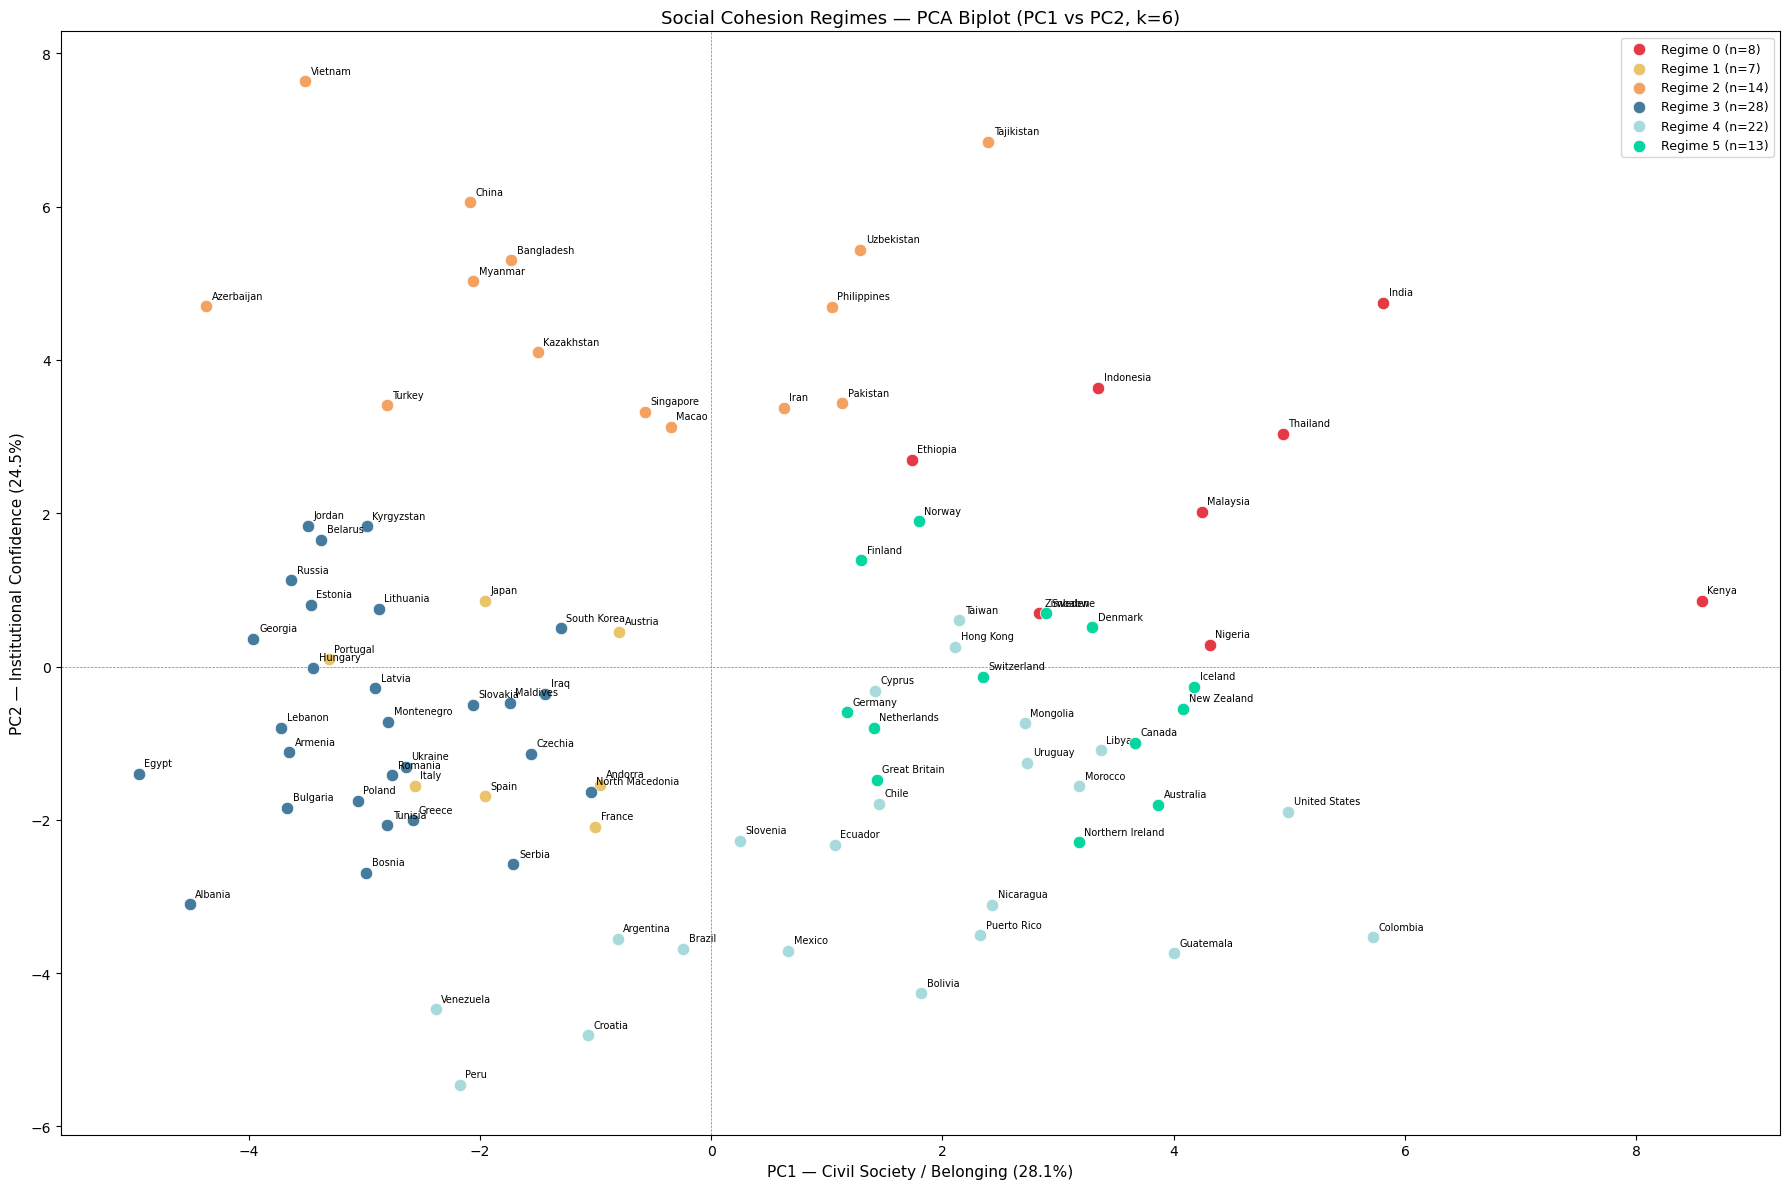

In [181]:
regime_colors_k6 = {
    0: '#E63946',
    1: '#E9C46A', 
    2: '#F4A261',
    3: '#457B9D',
    4: '#A8DADC',
    5: '#06D6A0'
}

regime_labels_k6 = {
    0: 'Regime 0',
    1: 'Regime 1',
    2: 'Regime 2',
    3: 'Regime 3',
    4: 'Regime 4',
    5: 'Regime 5'
}

fig, ax = plt.subplots(figsize=(18, 12))

for regime, group in df_country.groupby('regime_k6'):
    idx = group.index
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               c=regime_colors_k6[regime], label=f'{regime_labels_k6[regime]} (n={len(group)})',
               s=80, zorder=3, edgecolors='white', linewidths=0.5)
    for _, row in group.iterrows():
        i = df_country.index.get_loc(row.name)
        ax.annotate(row['country_name'], (X_pca[i, 0], X_pca[i, 1]),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(4, 4), textcoords='offset points')

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 — Civil Society / Belonging ({pca_gmm.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 — Institutional Confidence ({pca_gmm.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
ax.set_title('Social Cohesion Regimes — PCA Biplot (PC1 vs PC2, k=6)', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('Figures/gmm_biplot_k6.png', dpi=150, bbox_inches='tight')
plt.show()

In [182]:
import plotly.graph_objects as go

fig = go.Figure()

for regime, group in df_country.groupby('regime_k6'):
    idx = group.index
    fig.add_trace(go.Scatter3d(
        x=X_pca[idx, 0],
        y=X_pca[idx, 1],
        z=X_pca[idx, 2],
        mode='markers+text',
        marker=dict(size=6, color=regime_colors_k6[regime], opacity=0.8),
        text=group['country_name'],
        textposition='top center',
        textfont=dict(size=8),
        name=f'{regime_labels_k6[regime]} (n={len(group)})'
    ))

fig.update_layout(
    title='Social Cohesion Regimes — Interactive 3D PCA Plot (k=6)',
    scene=dict(
        xaxis_title=f'PC1 — Belonging ({pca_gmm.explained_variance_ratio_[0]*100:.1f}%)',
        yaxis_title=f'PC2 — Institutional Confidence ({pca_gmm.explained_variance_ratio_[1]*100:.1f}%)',
        zaxis_title=f'PC3 — Social Openness ({pca_gmm.explained_variance_ratio_[2]*100:.1f}%)'
    ),
    width=1000,
    height=700
)

fig.write_html('Figures/gmm_biplot_3d_k6.html')
fig.show()

Classification Uncertainty

While most countries are classified with high confidence, several exhibit meaningful uncertainty. Ethiopia has the highest entropy (0.927), reflecting near-equal posterior probabilities across Regimes 0 and 4. Other boundary cases include Zimbabwe and Nigeria, which show partial membership in Regime 4, and Portugal and Slovenia, which sit at the margins of their respective regimes. These cases are substantively interesting rather than methodological failures — they represent countries whose cohesion profiles do not map cleanly onto any single regime type.

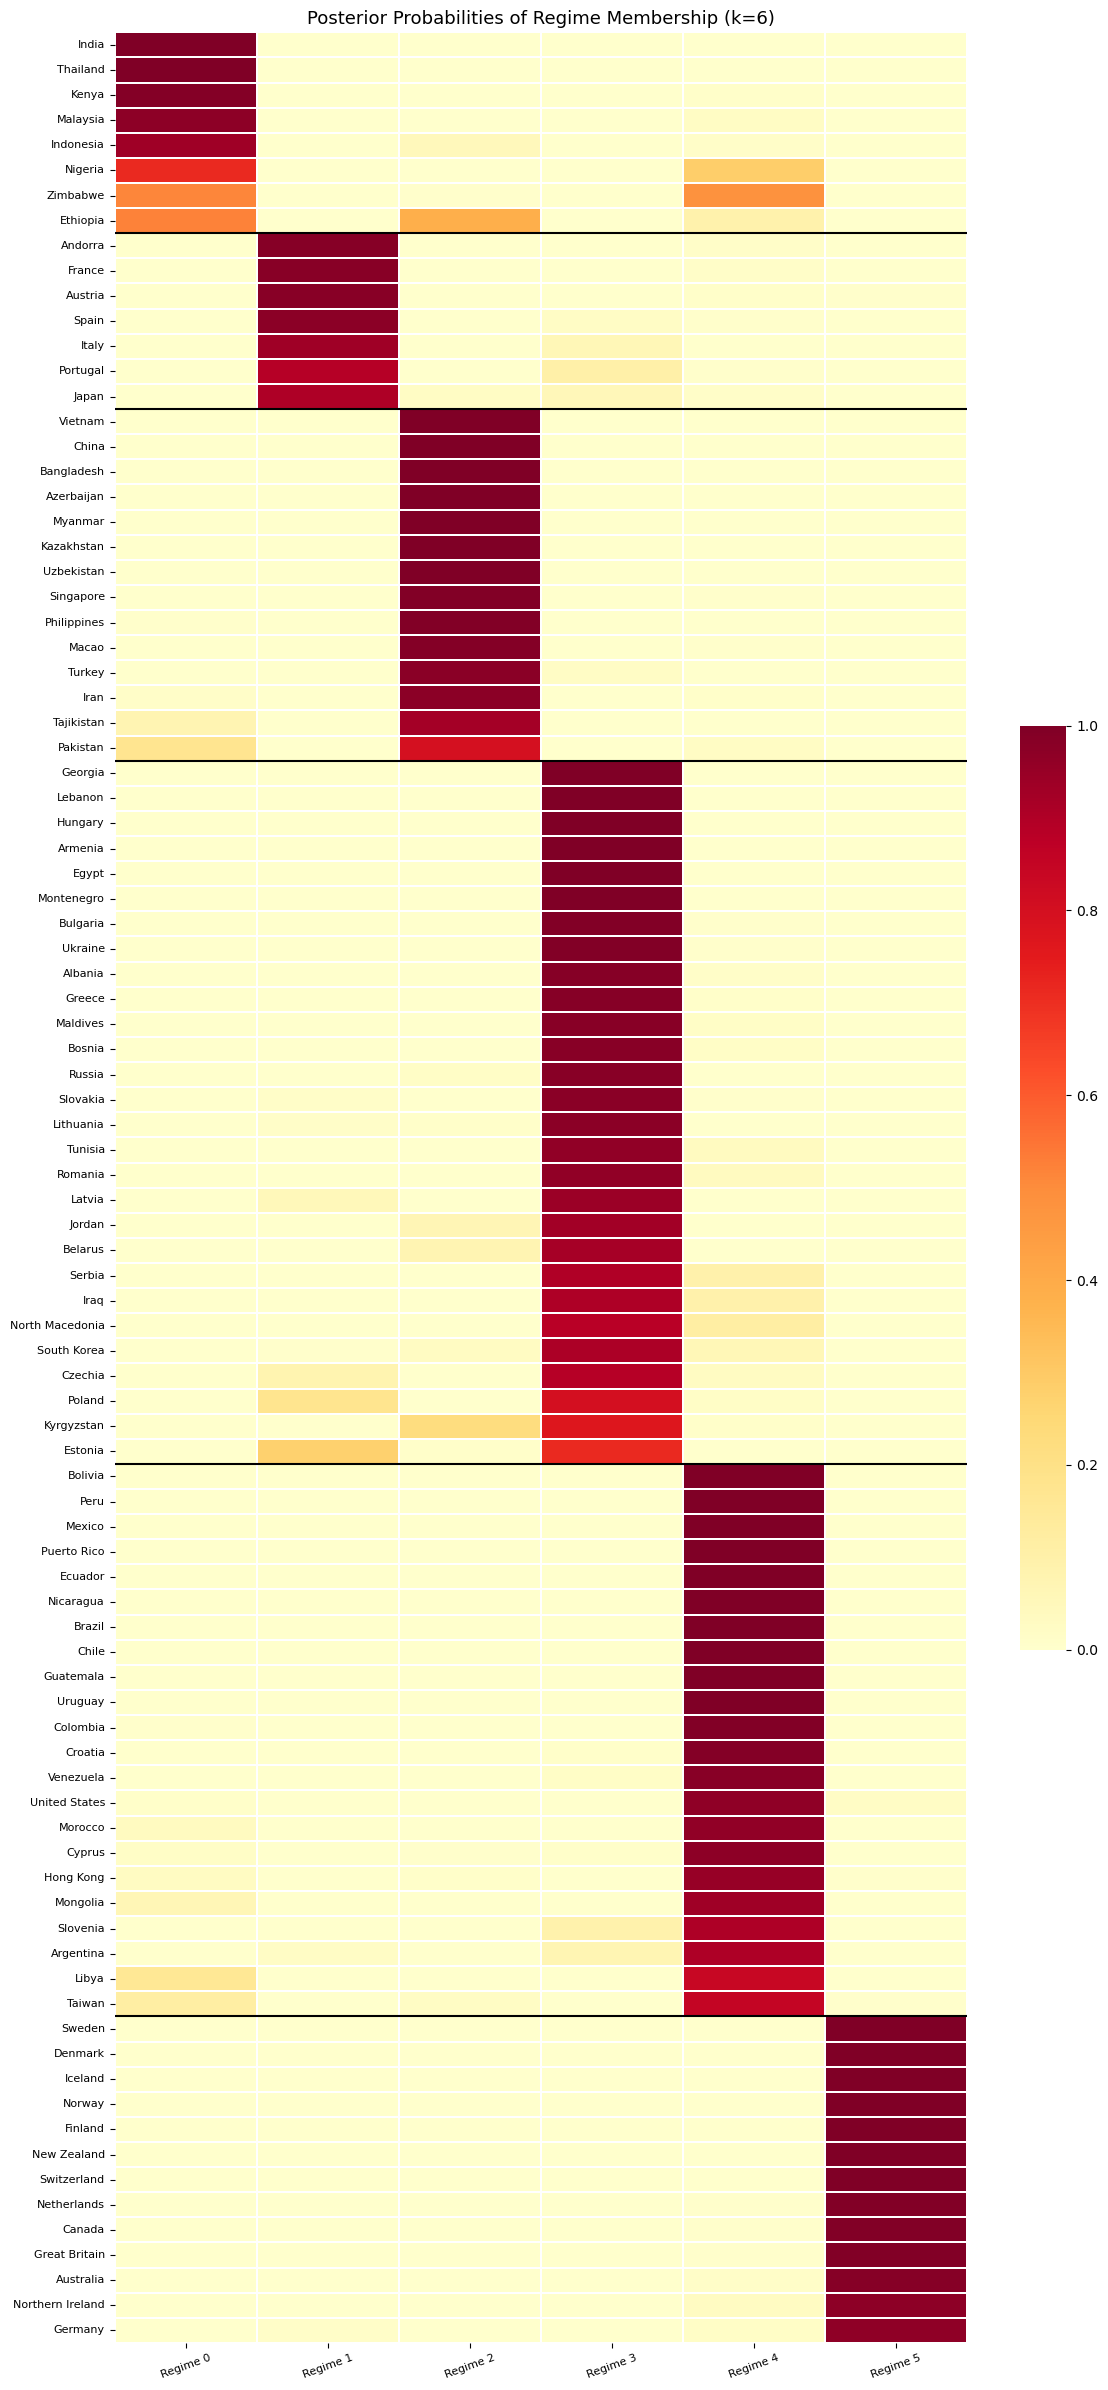

In [ ]:
prob_cols_k6 = [f'prob_regime_{i}' for i in range(6)]
heatmap_df = df_country[['country_name', 'regime_k6', 'entropy_k6'] + prob_cols_k6].copy()
heatmap_df = heatmap_df.sort_values(['regime_k6', 'entropy_k6'])
heatmap_df = heatmap_df.reset_index(drop=True)
heatmap_df = heatmap_df.set_index('country_name')

col_labels = [regime_labels_k6[i] for i in range(6)]

fig, ax = plt.subplots(figsize=(12, 24))
sns.heatmap(heatmap_df[prob_cols_k6], cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.4},
            xticklabels=col_labels)
ax.set_title('Posterior Probabilities of Regime Membership (k=6)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=8, rotation=20)
ax.tick_params(axis='y', labelsize=8)

regime_sorted = df_country.sort_values(['regime_k6', 'entropy_k6'])['regime_k6']
sizes = regime_sorted.value_counts().sort_index()
dividers = sizes.cumsum().values[:-1]
for d in dividers:
    ax.axhline(d, color='black', linewidth=1.5)

plt.tight_layout()
plt.savefig('Figures/gmm_heatmap_k6.png', dpi=150, bbox_inches='tight')
plt.show()

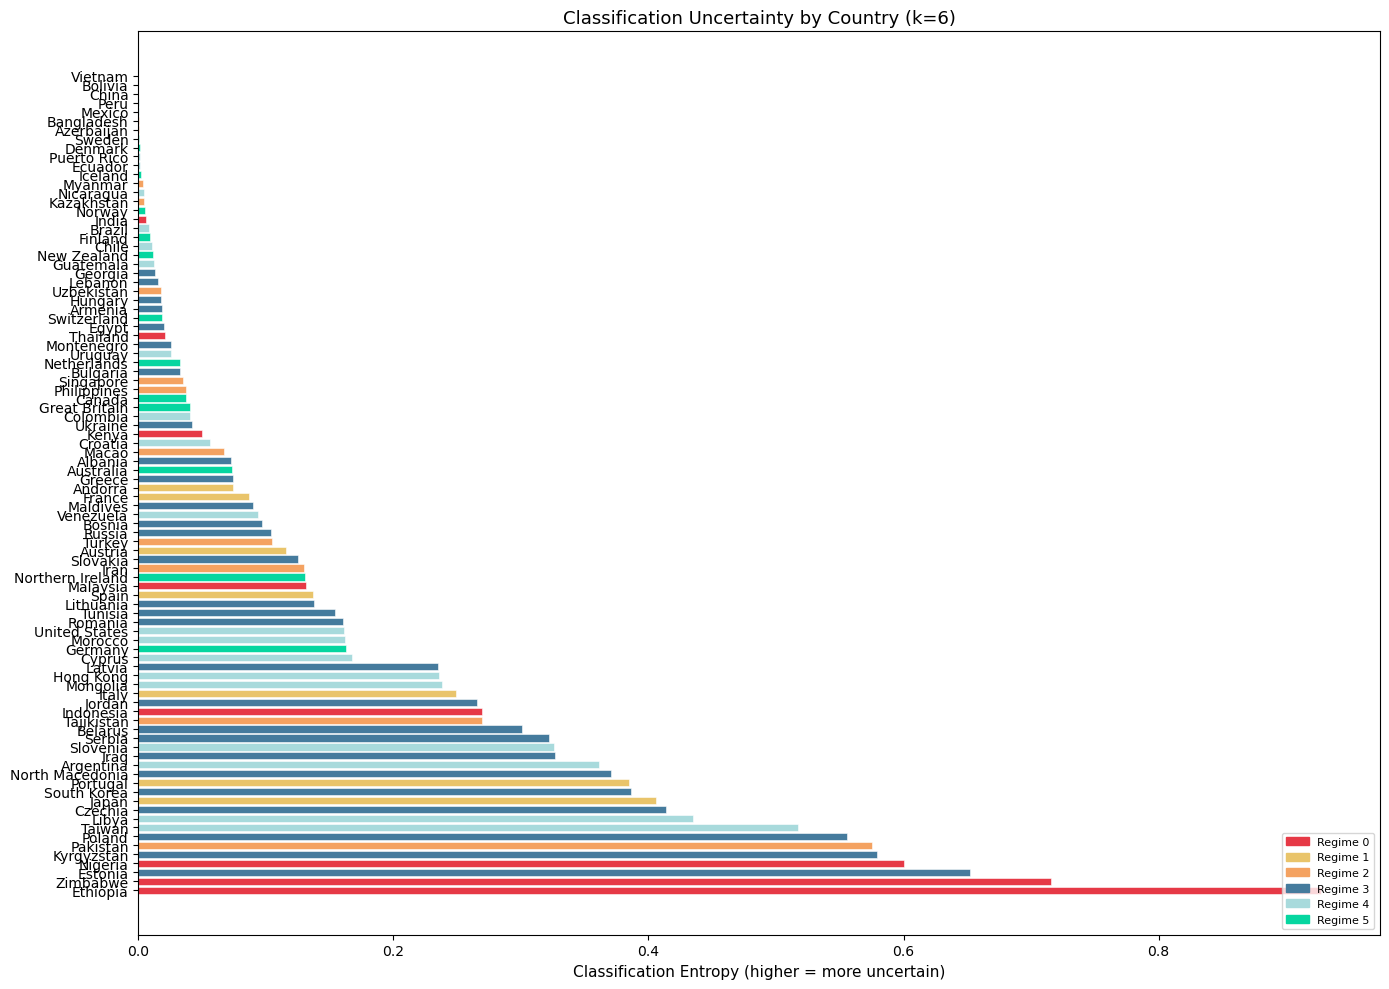

In [ ]:
import matplotlib.patches as mpatches

entropy_df = df_country[['country_name', 'entropy_k6', 'regime_k6']].copy()
entropy_df = entropy_df.sort_values('entropy_k6', ascending=False)

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(entropy_df['country_name'],
        entropy_df['entropy_k6'],
        color=[regime_colors_k6[r] for r in entropy_df['regime_k6']],
        edgecolor='white', linewidth=0.4)

ax.set_xlabel('Classification Entropy (higher = more uncertain)', fontsize=11)
ax.set_title('Classification Uncertainty by Country (k=6)', fontsize=13)

handles = [mpatches.Patch(color=regime_colors_k6[r], label=regime_labels_k6[r]) for r in range(6)]
ax.legend(handles=handles, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('Figures/gmm_entropy_k6.png', dpi=150, bbox_inches='tight')
plt.show()

Robustness

To assess the stability of the six-regime solution, an alternative GMM was estimated using a diagonal covariance structure and k=3 components (BIC=1661.8). This specification differs from the primary model in both covariance assumption and number of components, providing a meaningful test of whether the primary results are driven by modeling choices rather than genuine structure in the data.

The ARI between the primary and robustness models is 0.513. While moderate, this is expected given the structural difference between a six and three-component solution. Examining the country assignments reveals that the three most theoretically coherent regimes replicate cleanly: the Western Liberal cluster (Regime 5) maps perfectly onto a single robustness regime, the High-Conformity Asian cluster (Regime 2) maps almost perfectly, and the Post-Communist/MENA cluster (Regime 3) is nearly fully recovered. The robustness model merges the Sub-Saharan/Southeast Asian and Latin American clusters into a single regime, and partially absorbs Southern/Western Europe into the Post-Communist group. These merges reflect genuine proximity in cohesion space rather than instability in the primary solution.

In [187]:
gmm_robust = GaussianMixture(
    n_components=3,
    covariance_type='diag',
    n_init=50,
    random_state=42
)
gmm_robust.fit(X_pca)

probs_robust = gmm_robust.predict_proba(X_pca)
labels_robust = gmm_robust.predict(X_pca)
entropy_robust = -np.sum(probs_robust * np.log(probs_robust + 1e-10), axis=1)

df_country['regime_robust'] = labels_robust
df_country['entropy_robust'] = entropy_robust

print("Robustness model — regime sizes:")
print(df_country['regime_robust'].value_counts().sort_index())
print(f"\nMean entropy: {entropy_robust.mean():.3f}")
print(f"BIC: {gmm_robust.bic(X_pca):.3f}")

ari = adjusted_rand_score(labels_k6, labels_robust)
print(f"\nARI between primary (k=6) and robustness (k=3) model: {ari:.3f}")

print("\nCountry assignments:")
assignment_df = df_country[['country_name', 'regime_k6', 'regime_robust']].copy()
print(assignment_df.sort_values('regime_k6').to_string(index=False))

Robustness model — regime sizes:
regime_robust
0    37
1    41
2    14
Name: count, dtype: int64

Mean entropy: 0.183
BIC: 1661.828

ARI between primary (k=6) and robustness (k=3) model: 0.513

Country assignments:
    country_name  regime_k6  regime_robust
        Zimbabwe          0              1
        Thailand          0              1
         Nigeria          0              1
        Malaysia          0              1
           Kenya          0              1
           India          0              1
       Indonesia          0              1
        Ethiopia          0              1
        Portugal          1              0
           Japan          1              0
           Italy          1              0
          France          1              0
           Spain          1              0
         Andorra          1              0
         Austria          1              2
         Myanmar          2              1
       Singapore          2              1
      Tajik

Discussion

The results provide strong evidence for both parts of the research question. Six empirically distinguishable social cohesion regimes were identified in Wave 7 of the Joint EVS/WVS, and membership in these regimes is better understood as probabilistic than deterministic. The mean entropy of 0.157 indicates that most countries are assigned with high confidence, but meaningful boundary cases exist--Ethiopia, Zimbabwe, Portugal, and Slovenia among others--whose cohesion profiles straddle multiple regime types. These cases are not failures of the model but substantively informative findings: they identify countries undergoing cohesion transitions or exhibiting genuinely hybrid configurations.

The regime structure recovered here extends Janmaat (2011) in two important ways. First, it uses contemporary data and a broader indicator set, revealing a more differentiated global picture than was visible in 1999 WVS data. Second, and more importantly, it demonstrates that hard cluster assignments conceal real uncertainty. Treating regime membership as deterministic imposes a sharpness on cohesion boundaries that the data does not support.

The Western Liberal regime (Regime 5) and the High-Conformity Asian regime (Regime 2) are the most internally coherent, replicating cleanly across both the primary and robustness models. The Post-Communist/MENA regime (Regime 3) is the largest and most internally diverse, suggesting it may reflect a residual category as much as a coherent cohesion type. This is a limitation worth investigating with richer data or finer indicators.

There are several other limitations are worth noting. The unit of analysis is the country, which means within-country heterogeneity is suppressed by aggregation. A country like India or Nigeria almost certainly contains substantial internal variation in cohesion profiles that country-level means cannot capture. The analytical sample of 92 countries is also relatively small for mixture modeling, which constrains the complexity of covariance structures that can be reliably estimated. 

Future work could address these limitations by moving to subnational units of analysis or incorporating additional waves of WVS data to examine regime stability over time. The regime assignments produced here could also serve as outcomes in causal analyses examining the political and economic consequences of cohesion regime type.